In [ ]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import mean_squared_error as mse
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process.kernels import ExpSineSquared, WhiteKernel
from sklearn.ensemble import RandomForestRegressor as RF

In [ ]:
df= pd.read_csv('/content/AT.csv')
df

,TF,Max,Min,Mean,target
0,9.920000e-07,0.000108,751000.0,0.05330,0
1,2.790000e-06,0.000304,2110000.0,0.15000,0
2,3.140000e-05,0.003420,23800000.0,1.69000,0
3,1.600000e-05,0.001740,12100000.0,0.85800,0
4,2.120000e-06,0.000231,1600000.0,0.11400,0
...,...,...,...,...,...
995,3.430000e-11,0.000003,860000.0,0.00151,1
996,3.460000e-11,0.000003,867000.0,0.00152,1
997,3.480000e-11,0.000003,873000.0,0.00154,1
998,3.510000e-11,0.000003,880000.0,0.00155,1


In [ ]:
from sklearn.utils import shuffle
df1 = shuffle(df, random_state=42)
x_1 = df1.iloc[:,0:4]
x_1

,TF,Max,Min,Mean
521,2.540000e-09,2.440000e-04,63600000.0,0.112000
737,2.780000e-11,2.670000e-06,696000.0,0.001220
740,6.880000e-11,6.610000e-06,1720000.0,0.003030
660,8.160000e-11,7.840000e-06,2040000.0,0.003590
411,3.090000e-08,3.370000e-06,23400.0,0.001660
...,...,...,...,...
106,2.830000e-08,3.080000e-06,21400.0,0.001520
270,1.110000e-09,1.210000e-07,840.0,0.000060
860,4.460000e-12,4.290000e-07,112000.0,0.000196
435,6.350000e-09,6.920000e-07,4810.0,0.000341


In [ ]:
y_1 = df1["target"]
y_1

,target
521,1
737,1
740,1
660,1
411,0
...,...
106,0
270,0
860,1
435,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_1, y_1, test_size=0.20, random_state=42)
x_train.to_csv("x_train.csv")
x_train

,TF,Max,Min,Mean
947,3.150000e-11,3.030000e-06,790000.0,0.001390
434,6.220000e-09,6.780000e-07,4710.0,0.000334
262,1.690000e-09,1.840000e-07,1280.0,0.000091
268,1.210000e-09,1.320000e-07,915.0,0.000065
642,1.430000e-10,1.380000e-05,3600000.0,0.006320
...,...,...,...,...
554,1.020000e-10,9.780000e-06,2550000.0,0.004480
490,1.840000e-08,2.000000e-06,13900.0,0.000988
378,5.640000e-09,6.140000e-07,4270.0,0.000303
12,5.200000e-08,5.660000e-06,39400.0,0.002790


In [ ]:
y_train.to_csv("y_train.csv")
y_train

,target
947,1
434,0
262,0
268,0
642,1
...,...
554,1
490,0
378,0
12,0


In [ ]:
x_test.to_csv("x_test.csv")
x_test

,TF,Max,Min,Mean
666,1.230000e-11,1.180000e-06,307000.0,0.000540
129,6.580000e-07,7.160000e-05,498000.0,0.035300
784,4.640000e-12,4.460000e-07,116000.0,0.000204
152,1.350000e-07,1.470000e-05,102000.0,0.007260
920,1.190000e-10,1.140000e-05,2980000.0,0.005230
...,...,...,...,...
51,4.420000e-09,4.820000e-07,3350.0,0.000238
722,1.090000e-11,1.050000e-06,273000.0,0.000481
495,2.390000e-08,2.600000e-06,18100.0,0.001280
712,7.700000e-12,7.410000e-07,193000.0,0.000339


In [ ]:
y_test.to_csv("y-test.csv")
y_test

,target
666,1
129,0
784,1
152,0
920,1
...,...
51,0
722,1
495,0
712,1


# **RFC**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
RandomForestClassifier.get_params

<function sklearn.base.BaseEstimator.get_params(self, deep=True)>

In [ ]:
rfc = RandomForestClassifier(criterion = 'entropy', random_state=100, max_depth = 25)

In [ ]:
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 25,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 100,
 'verbose': 0,
 'warm_start': False}

In [ ]:
rfc.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=25, random_state=100)

In [ ]:
y_pred_rf = rfc.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_rf)))

Model accuracy score with 10 decision-trees : 0.9950


In [ ]:
print('Training set score: {:.4f}'.format(rfc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(rfc.score(x_test, y_test)))

Training set score: 1.0000
Test set score: 0.9950


In [ ]:
y_pred = rfc.predict(x_test)

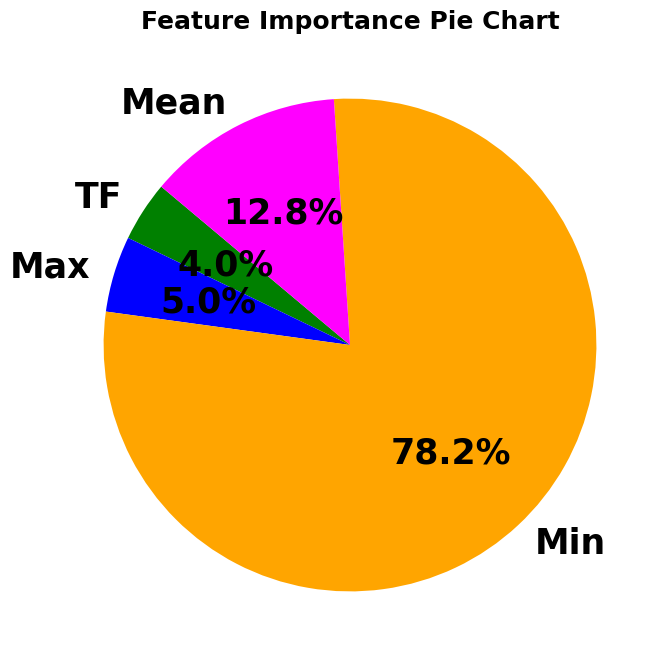

In [ ]:
feature_importances = rfc.feature_importances_

# Get the names of the features (replace with your feature names if available)
feature_names = ["TF", "Max", "Min", "Mean"]
# Create a pie chart
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(feature_importances, labels=feature_names, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 54}, colors=['green', 'blue', 'orange','magenta'])

# Increase font size and make feature names bold
for text in texts + autotexts:
    text.set_size(25)  # Adjust the font size as needed
    text.set_weight('bold')

plt.title('Feature Importance Pie Chart', fontsize=18, weight='bold')
plt.show()

In [ ]:
import numpy as np

In [ ]:
feature_scores = pd.Series(rfc.feature_importances_, index=pd.DataFrame(x_train).columns).sort_values(ascending=False)
feature_scores

,0
Min,0.799668
Mean,0.101325
Max,0.058135
TF,0.040872


In [ ]:
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 25,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 100,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
class_accuracy = {}
for class_label in set(y_test):
    class_indices = (y_test == class_label)
    class_accuracy[class_label] = accuracy_score(y_test[class_indices], y_pred_rf[class_indices])

In [ ]:
print('\nAccuracy for each class:')
for class_label, acc in class_accuracy.items():
    print(f'Class {class_label}: {acc:.4f}')


Accuracy for each class:
Class 0: 1.0000
Class 1: 1.0000


In [ ]:
!pip install scikit-learn
from sklearn.metrics import confusion_matrix
import numpy as np

# Fix the variable name
conf_matrix = confusion_matrix(y_test, y_pred_rf)

class_selectivity = {}
for i, class_label in enumerate(set(y_test)):
    tn = conf_matrix[i, i]  # True Negatives
    fp = np.sum(conf_matrix[:, i]) - tn  # False Positives

    if (tn + fp) > 0:
        class_selectivity[class_label] = tn / (tn + fp)
    else:
        class_selectivity[class_label] = 0.0

# Print selectivity for each class
print('\nSelectivity for each class:')
for class_label, selectivity in class_selectivity.items():
    print(f'Class {class_label}: {selectivity:.4f}')


Selectivity for each class:
Class 0: 1.0000
Class 2: 1.0000


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_rf)
class_sensitivity = {}
for i, class_label in enumerate(set(y_test)):
    tp = conf_matrix[i, i]  # True Positives
    fn = np.sum(conf_matrix[i, :]) - tp  # False Negatives

    if (tp + fn) > 0:
        class_sensitivity[class_label] = tp / (tp + fn)
    else:
        class_sensitivity[class_label] = 0.0

# Calculate weighted average sensitivity
weighted_sensitivity = np.average(list(class_sensitivity.values()), weights=[np.sum(y_test == label) for label in class_sensitivity.keys()])

# Print weighted average sensitivity
print(f'\nWeighted Average Sensitivity (Recall): {weighted_sensitivity:.4f}')


Weighted Average Sensitivity (Recall): 0.8679


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_rf)
class_sensitivity = {}
for i, class_label in enumerate(set(y_test)):
    tp = conf_matrix[i, i]  # True Positives
    fn = np.sum(conf_matrix[i, :]) - tp  # False Negatives

    if (tp + fn) > 0:
        class_sensitivity[class_label] = tp / (tp + fn)
    else:
        class_sensitivity[class_label] = 0.0

# Print sensitivity for each class
print('\nSensitivity (Recall) for each class:')
for class_label, sensitivity in class_sensitivity.items():
    print(f'Class {class_label}: {sensitivity:.4f}')


Sensitivity (Recall) for each class:
Class dCMP: 0.8585
Class dTMP: 0.8229
Class dGMP: 0.9252
Class dAMP: 0.8571


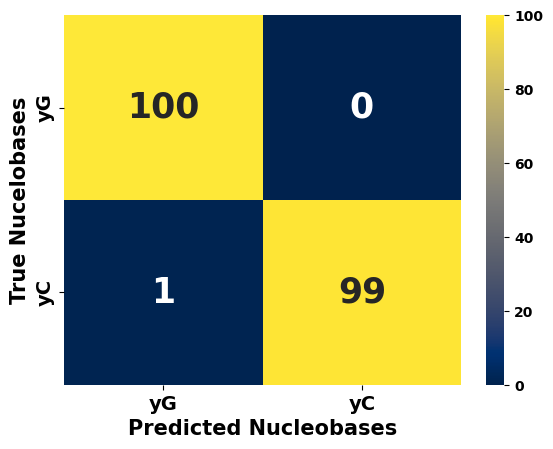

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Assuming y_test and y_pred_rf are defined

cm = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(cm,
                     index=['yG', 'yC', ],
                     columns=['yG', 'yC',])
colors = ['red', 'yellow']
# Create heatmap with bold annotations
sns.heatmap(cm_df, cbar=True,annot=True,cmap="cividis", fmt="d",annot_kws={"size": 25, 'weight': 'bold'})

plt.ylabel('True Nucelobases', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleobases', fontsize = 15,weight='bold')
#plt.title('RFC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
plt.show()


In [ ]:
print(x_test.columns)

Index(['TF', 'Max', 'Min', 'Mean'], dtype='object')


In [ ]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 10.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generate the learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    rfc, x_train, y_train, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

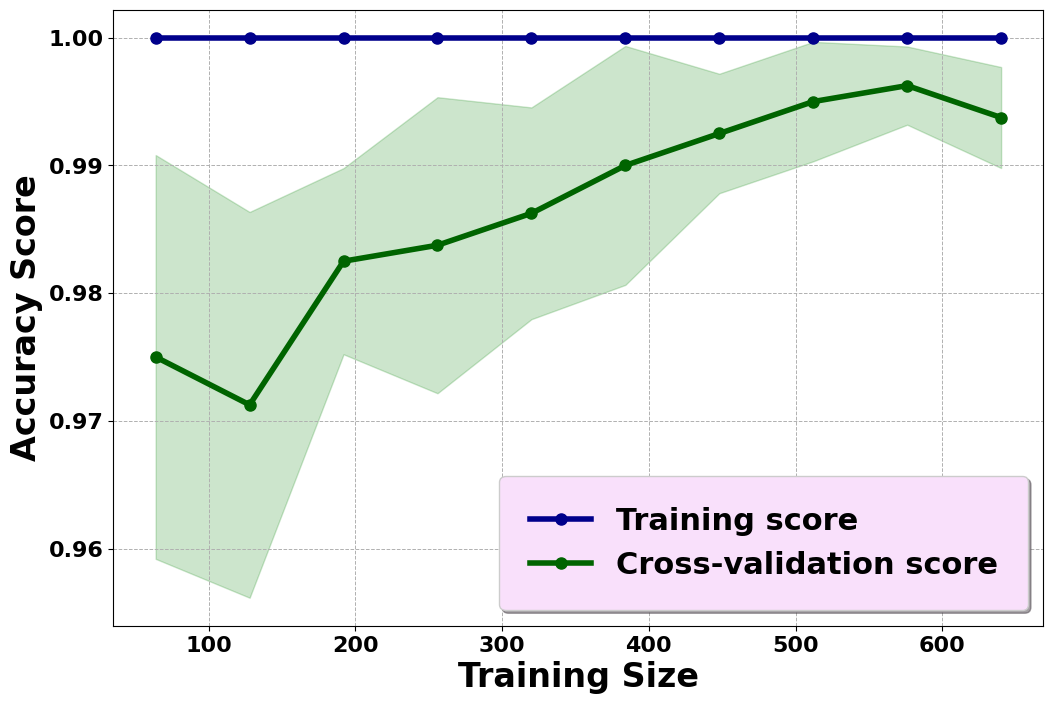

In [ ]:
# Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve with enhanced visualization
plt.figure(figsize=(12, 8))

# Plotting the learning curves
plt.plot(train_sizes, train_scores_mean, 'o-', color='darkblue', label='Training score', linewidth=4, markersize=8)
plt.plot(train_sizes, test_scores_mean, 'o-', color='darkgreen', label='Cross-validation score', linewidth=4, markersize=8)

# Adding the standard deviation as shaded areas
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.2, color='green')

# Add labels and title with increased font size
#plt.title('Learning Curve for RandomForestClassifier', fontsize=20, weight='bold')
plt.xlabel('Training Size', fontsize=24, weight='bold')
plt.ylabel('Accuracy Score', fontsize=24, weight='bold')

# Customize ticks and grid
plt.xticks(fontsize=16, weight='bold')
plt.yticks(fontsize=16, weight='bold')
plt.grid(True, linestyle='--', linewidth=0.7)

# Customize the legend
legend = plt.legend(loc='lower right', fontsize=22, frameon=True, fancybox=True, framealpha=1, shadow=True, borderpad=1)

# Set legend line width (thicker lines in the legend)
for line in legend.get_lines():
    line.set_linewidth(4.0)

# Set legend background color
legend.get_frame().set_facecolor('#f9e0fb')  # Light grey background

# Show the plot
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming y_test and y_score are defined
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Average Precision = {avg_precision:.2f}')
plt.xlabel('Recall', fontsize=14, weight='bold')
plt.ylabel('Precision', fontsize=14, weight='bold')
plt.title('Precision-Recall Curve', fontsize=16, weight='bold')
plt.legend(loc='lower left')
plt.show()

NameError: name 'y_score' is not defined

# **Prediction**

In [ ]:
df5= pd.read_csv('/content/xC0.csv')
x_t = df5.iloc[:,0:4]
y_t = df5["Target"]

In [ ]:
y_pred_t = rfc.predict(x_t)
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_t, y_pred_t)))

Model accuracy score with 10 decision-trees : 0.0000


In [ ]:
y_pred_t

array(['xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'x

In [ ]:
from google.colab import files
import pandas as pd
df = pd.DataFrame(y_pred_t)
df.to_csv('yA_pred.csv')
files.download('yA_pred.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
class_accuracy = {}
for class_label in set(y_t):
    class_indices = (y_t == class_label)
    class_accuracy[class_label] = accuracy_score(y_t[class_indices], y_pred_t[class_indices])

In [ ]:
print('\nAccuracy for each class:')
for class_label, acc in class_accuracy.items():
    print(f'Class {class_label}: {acc:.4f}')


Accuracy for each class:
Class dTMP: 0.9200


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_t, y_pred_t))

              precision    recall  f1-score   support

        dAMP       0.00      0.00      0.00         0
        dCMP       0.00      0.00      0.00         0
        dGMP       0.00      0.00      0.00         0
        dTMP       1.00      0.92      0.96       500

    accuracy                           0.92       500
   macro avg       0.25      0.23      0.24       500
weighted avg       1.00      0.92      0.96       500



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


TypeError: only integer scalar arrays can be converted to a scalar index

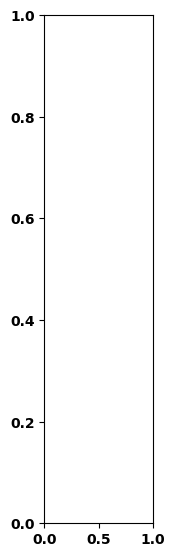

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
feature_names=list(x_test.columns.values)
#class_names = ['dAMP','dCMP','dGMP','dTMP']

# Create the SHAP explainer with the trained model
explainer = shap.TreeExplainer(rfc)

# Compute SHAP valuesfc
shap_values = explainer.shap_values(x_train)
class_colors = ["#E69F00", "#56B4E9", "#D55E00", "#0073C2"]
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.color'] = 'black'
# Plot the SHAP summary plot
shap.summary_plot(shap_values, x_test, plot_type="bar", class_names=class_names, feature_names=feature_names)
plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

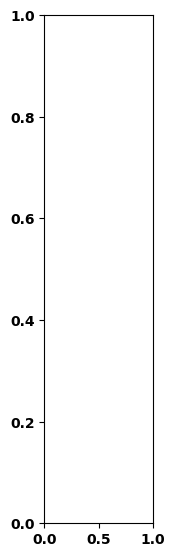

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
#feature_names = list(x_test.columns)
class_names = ['xA','xT']

# Create the SHAP explainer with the trained model
explainer = shap.TreeExplainer(rfc)

# Compute SHAP valuesfc
shap_values = explainer.shap_values(x_test)
class_colors = ["#E69F00", "#56B4E9", "#D55E00", "#0073C2"]
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.color'] = 'black'
# Plot the SHAP summary plot
shap.summary_plot(shap_values, x_test, plot_type="bar", class_names=class_names, feature_names=feature_names)
plt.show()

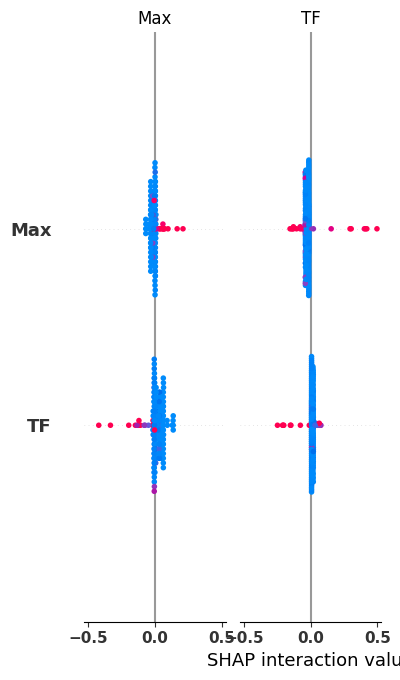

In [ ]:
shap.initjs()
shap.summary_plot(shap_values, x_test)

In [ ]:
%%capture
!pip install probatus

In [ ]:
import warnings

import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from probatus.interpret import ShapModelInterpreter

warnings.filterwarnings("ignore")

feature_names = ["TF", "Max", "Min", "Mean"]

In [ ]:
shap_interpreter = ShapModelInterpreter(rfc)
shap_interpreter.fit(x_train, y_train, x_test, y_test)

TypeError: Please supply a list, numpy array, pandas Series

In [ ]:
ax = shap_interpreter.plot("dependence", target_columns=["TF"])

AttributeError: 'ShapModelInterpreter' object has no attribute 'shap_values_test'